<a href="https://colab.research.google.com/github/luxon7/credit-card-fraud-detection-projekat/blob/main/Projekat_Duboko_Ucenje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Prvih 5 redova dataseta ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   



/tmp/ipykernel_1054/1940941721.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Dark2')


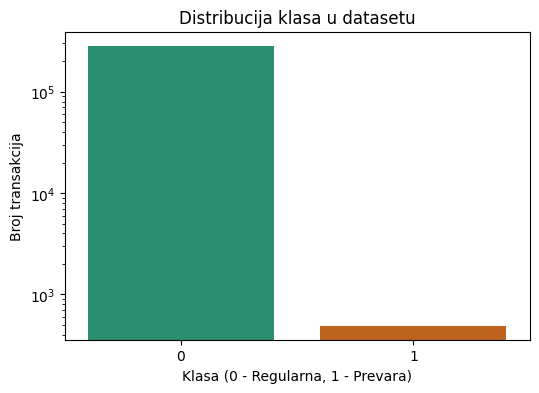


--- Statistika iznosa za regularne transakcije ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Statistika iznosa za prevare ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [5]:
# Ucitavanje biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Učitavanje dataseta
df = pd.read_csv('creditcard.csv')

# Prikaz prvih nekoliko redova
print("--- Prvih 5 redova dataseta ---")
print(df.head())

print("\n--- Distribucija klasa (0 = Regularna, 1 = Prevara) ---")
print(df['Class'].value_counts())

print("\n--- Procentualni udeo prevara ---")
print(df['Class'].value_counts(normalize=True) * 100)

# Vizuelizacija debalansa
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Dark2')
plt.title('Distribucija klasa u datasetu')
plt.xlabel('Klasa (0 - Regularna, 1 - Prevara)')
plt.ylabel('Broj transakcija')
plt.yscale('log') # Logaritamska skala jer je razlika ogromna
plt.show()


print("\n--- Statistika iznosa za regularne transakcije ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Statistika iznosa za prevare ---")
print(df[df['Class'] == 1]['Amount'].describe())

In [6]:
# Import klasa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kopija dataseta
data = df.copy()

# Inicijalizuja StandardScaler-a (prosek 0, a standardna devijacija 1)
scaler = StandardScaler()

# Skaliranje kolona Amount i Time, jer njihove vrednosti odskacu
data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

# Brisanje starih kolona
data = data.drop(['Time', 'Amount'], axis=1)

# X su svi ulazni podaci (karakteristike transakcije)
X = data.drop('Class', axis=1)

# y je target (0 ili 1)
y = data['Class']

# Podela na train i test (80% train 20% test)
# random_state=42 osigurava da svaki put dobijemo istu podelu podataka
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Dimenzije podataka nakon podele ---")
print(f"Trening set (X_train): {X_train.shape}")
print(f"Test set (X_test): {X_test.shape}")

print("\n--- Provera debalansa u Trening setu ---")
print(y_train.value_counts(normalize=True) * 100)

--- Dimenzije podataka nakon podele ---
Trening set (X_train): (227845, 30)
Test set (X_test): (56962, 30)

--- Provera debalansa u Trening setu ---
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


In [7]:
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Računamo težine klasa kako bismo balansirali trening
# Pošto ima previše nula, klasa 1 će dobiti ogroman koeficijent
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Pretvaramo u rečnik koji Keras prepoznaje
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("--- Težine klasa koje šaljemo modelu ---")
print(f"Klasa 0 (Regularne): {class_weight_dict[0]:.4f}")
print(f"Klasa 1 (Prevare): {class_weight_dict[1]:.4f}")

model = Sequential([
    # Ulazni sloj i prvi skriveni sloj (32 neurona, ReLU aktivacija)
    # input_shape=30 jer imamo tačno 30 ulaznih kolona
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),

    # Dropout sloj koji nasumično "gasi" 20% neurona tokom treninga (sprečava overfitting)
    Dropout(0.2),

    # Drugi skriveni sloj (16 neurona, ReLU aktivacija)
    Dense(16, activation='relu'),

    # Izlazni sloj (1 neuron, Sigmoid aktivacija za dobijanje verovatnoće između 0 i 1)
    Dense(1, activation='sigmoid')
])

#Kompilacija modela
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', # Standard za binarnu klasifikaciju (0 ili 1)
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n--- Sažetak arhitekture modela ---")
model.summary()

print("\n--- Trening započinje... ---")
history = model.fit(
    X_train, y_train,
    epochs=10,                # Broj prolazaka kroz ceo dataset
    batch_size=2048,          # Koliko transakcija mreža vidi odjednom pre nego što ažurira težine
    validation_split=0.1,     # Odvajamo 10% trening podataka za praćenje rezultata tokom učenja
    class_weight=class_weight_dict, # Ubacujemo izračunate težine za balansiranje
    verbose=1
)

--- Težine klasa koje šaljemo modelu ---
Klasa 0 (Regularne): 0.5009
Klasa 1 (Prevare): 289.1434

--- Sažetak arhitekture modela ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Trening započinje... ---
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5877 - precision: 0.0042 - recall: 0.7364 - val_loss: 0.4536 - val_precision: 0.0164 - val_recall: 0.9333
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2844 - precision: 0.0223 - recall: 0.8711 - val_loss: 0.2374 - val_precision: 0.0897 - val_recall: 0.9333
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2168 - precision: 0.0486 - recall: 0.8739 - val_loss: 0.1711 - val_precision: 0.0911 - val_recall: 0.9333
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1815 - precision: 0.0545 - recall: 0.8797 - val_loss: 0.1358 - val_precision: 0.0986 - val_recall: 0.9333
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1847 - precision: 0.0508 - recall: 0.8739 - val_loss: 0.1349 - val_precision: 0.0762 - val_recall: 0.9333
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1616 - precision: 0.0544 - recall: 0.8997 - val_loss: 0.1166 - val_